# Paper Figures & Tables

Distilled notebook for the ICML workshop paper. Produces:
1. **Headline discovery metrics** table (Table 1): $N^{\text{stable}}$, normalized, AUDC$_\text{norm}$, SDE.
2. **Cross-episode learning figure** (replaces slope table): per-episode mean $N_k^{\text{stable}}$ with linear fits and slope annotations.
3. **Exploration metrics** table and figure: # unique compositions, spacegroup entropy, mean $\Delta_\text{hull}$.
4. (Bonus) **Tier breakdown** table for the harder-systems claim and a **matched-pair** delta table.

All figures are saved as PDFs into `../../ICML_workshop/figs/` so they can be `\includegraphics`'d directly.
Data loading reuses the aggregation logic from `results_analysis_reflexion.ipynb`.

In [18]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'figure.dpi': 110,
    'savefig.bbox': 'tight',
})

FIG_DIR = Path('../../ICML_workshop/figs')
FIG_DIR.mkdir(parents=True, exist_ok=True)

results_base = Path('../results/smoke/custom')
configs = [
    'qwen3-30b-instr-noreflx', 'qwen3-30b-instr-reflx',
    'qwen3dot5-122b-noreflx', 'qwen3dot5-122b-reflx',
]
TIERS = ['ternary', 'quaternary', 'quinary']

PRETTY = {
    'qwen3-30b-instr-noreflx':  'Qwen3-30B / Base',
    'qwen3-30b-instr-reflx':    'Qwen3-30B / Reflx',
    'qwen3dot5-122b-noreflx':   'Qwen3.5-122B / Base',
    'qwen3dot5-122b-reflx':     'Qwen3.5-122B / Reflx',
}
COLORS = {
    'qwen3-30b-instr-noreflx':  '#1f6fbf',
    'qwen3-30b-instr-reflx':    '#82bef5',
    'qwen3dot5-122b-noreflx':   '#c95f00',
    'qwen3dot5-122b-reflx':     '#ffb06b',
}

## Data loading
Same logic as `results_analysis_reflexion.ipynb`: keep only the latest timestamped run per `(config, tier)` so interrupted episodes don't leak in.

In [19]:
def aggregate_results(results_base, configs):
    rows = []
    for config in configs:
        cfg_path = results_base / config
        if not cfg_path.exists():
            print(f'Warning: {cfg_path} missing')
            continue
        for tier in TIERS:
            for td in cfg_path.glob(f'systems_{tier}_*'):
                date_dirs = sorted(d for d in td.iterdir() if d.is_dir() and not d.name.startswith('.'))
                if not date_dirs:
                    continue
                latest = date_dirs[-1]
                for csv_path in latest.glob('**/systems/*/summary/episodes.csv'):
                    system_name = csv_path.parent.parent.name
                    df = pd.read_csv(csv_path)
                    df['config'] = config
                    df['model'] = config.replace('-noreflx', '').replace('-reflx', '')
                    df['reflexion'] = ('reflx' in config) and ('noreflx' not in config)
                    df['system'] = system_name
                    df['tier'] = tier
                    df = df.rename(columns={'episode_id': 'episode'})
                    rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

full_df = aggregate_results(results_base, configs)
full_df['discoveries_per_gt'] = (
    full_df['final/num_newly_discovered_stable']
    / full_df['final/num_ground_truth_stable_formulas'].clip(lower=1)
)
print(f'Loaded {len(full_df)} episodes / {full_df.system.nunique()} systems.')
full_df.groupby(['config', 'tier']).agg(systems=('system','nunique'), episodes=('episode','count'))

Loaded 832 episodes / 30 systems.


systems  episodes
config                  tier                         
qwen3-30b-instr-noreflx quaternary       10        80
                        quinary          10        80
                        ternary          10        80
qwen3-30b-instr-reflx   quaternary       10        80
                        quinary          10        80
                        ternary          10        80
qwen3dot5-122b-noreflx  quaternary        5        40
                        quinary           8        64
                        ternary           7        56
qwen3dot5-122b-reflx    quaternary        7        56
                        quinary           8        64
                        ternary           9        72

## 1. Headline discovery metrics (Table 1)
Per-episode means across all systems for each config. Columns map directly to the LaTeX table in `main.tex`:
$N^{\text{stable}}$, $/|S_\text{gt}|$, AUDC$_\text{norm}$, SDE.

In [20]:


HEADLINE_METRICS = {
    'final/num_newly_discovered_stable':                              '$N^{stable}$',
    'discoveries_per_gt':                                             '$/|S_{gt}|$',
    'final/discovery_curve_area_under_discovery_curve_normalized':    'AUDC_norm',
    'final/stable_discovery_efficiency':                              'SDE',
}

headline = (
    full_df.groupby('config')[list(HEADLINE_METRICS)]
           .mean()
           .rename(columns=HEADLINE_METRICS)
           .reindex(configs)
           .round(3)
)
headline.index = [PRETTY[c] for c in headline.index]
headline

,$N^{stable}$,$/|S_{gt}|$,AUDC_norm,SDE
Qwen3-30B / Base,9.821,0.571,0.267,0.246
Qwen3-30B / Reflx,14.429,0.837,0.385,0.361
Qwen3.5-122B / Base,15.625,0.899,0.391,0.391
Qwen3.5-122B / Reflx,21.026,1.218,0.544,0.526


In [21]:
# LaTeX-ready output (paste into Table 1 in main.tex).
print(headline.to_latex(escape=False, column_format='lcccc'))

\begin{tabular}{lcccc}
\toprule
 & $N^{stable}$ & $/|S_{gt}|$ & AUDC_norm & SDE \\
\midrule
Qwen3-30B / Base & 9.821000 & 0.571000 & 0.267000 & 0.246000 \\
Qwen3-30B / Reflx & 14.429000 & 0.837000 & 0.385000 & 0.361000 \\
Qwen3.5-122B / Base & 15.625000 & 0.899000 & 0.391000 & 0.391000 \\
Qwen3.5-122B / Reflx & 21.026000 & 1.218000 & 0.544000 & 0.526000 \\
\bottomrule
\end{tabular}



## 2. Cross-episode learning figure (replaces slope table)
For each config, we plot the per-episode mean of $N_k^{\text{stable}}$ (with SEM band) and overlay a linear fit. The fitted slope is annotated in the legend. Base configs should sit near zero (episodes are i.i.d. under reset); a clearly positive Reflx slope is the cross-episode learning signal.

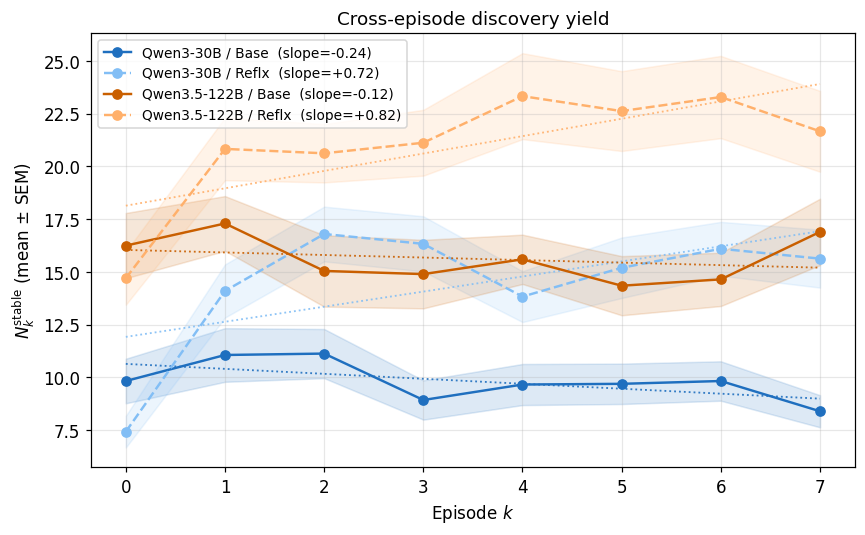

In [22]:
METRIC = 'final/num_newly_discovered_stable'

fig, ax = plt.subplots(figsize=(8, 5))

for c in configs:
    sub = full_df[full_df['config'] == c]
    if sub.empty:
        continue
    g = sub.groupby('episode')[METRIC]
    mean = g.mean(); sem = g.std() / np.sqrt(g.count())
    x = mean.index.values.astype(float)
    y = mean.values

    slope, intercept = np.polyfit(sub['episode'].astype(float), sub[METRIC].astype(float), 1)
    is_reflx = ('reflx' in c) and ('noreflx' not in c)
    ls = '--' if is_reflx else '-'
    color = COLORS[c]
    label = f'{PRETTY[c]}  (slope={slope:+.2f})'

    ax.plot(x, y, marker='o', linestyle=ls, color=color, label=label, linewidth=1.6)
    ax.fill_between(x, y - sem.values, y + sem.values, color=color, alpha=0.15)
    xfit = np.array([x.min(), x.max()])
    ax.plot(xfit, slope * xfit + intercept, linestyle=':', color=color, linewidth=1.2, alpha=0.9)

ax.set_xlabel('Episode $k$')
ax.set_ylabel(r'$N_k^{\mathrm{stable}}$ (mean $\pm$ SEM)')
ax.set_title('Cross-episode discovery yield')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cross_episode_slopes.pdf')
plt.show()

In [23]:
# Per-system slope distribution (the 'is the tilt outlier-driven?' check).
per_sys = []
for (cfg, sysname), sub in full_df[full_df['reflexion']].groupby(['config', 'system']):
    if len(sub) < 3:
        continue
    m, _ = np.polyfit(sub['episode'].astype(float), sub[METRIC].astype(float), 1)
    per_sys.append({'config': cfg, 'system': sysname, 'slope': m})
per_sys_df = pd.DataFrame(per_sys)
(per_sys_df.groupby('config')['slope']
    .agg(mean='mean', median='median',
         n_positive=lambda s: int((s > 0).sum()),
         n_total='count')
    .round(3))

,mean,median,n_positive,n_total
config,,,,
qwen3-30b-instr-reflx,0.715,0.530,24,30
qwen3dot5-122b-reflx,0.824,0.226,14,24


### Cross-episode learning summary (Section 4 / line 208 claims)
Consolidates the three metrics promised in the Evaluation Metrics section:
1. **Mean matched-pair delta** $\bar\Delta_{\text{ref}}$ — per-system mean of $\bar N^{\text{reflx}}_s - \bar N^{\text{base}}_s$
2. **Win fraction** — fraction of matched systems where reflexion beats base
3. **Slope sign distribution** — fraction of per-system runs with a positive slope (both conditions)

## 3. Exploration metrics (Table 3 + figure)
Number of unique compositions queried per episode, spacegroup entropy of the known set, and mean $\Delta_\text{hull}$ of sampled structures. Together these tell the breadth$\to$depth story.

In [24]:
EXPLORATION_METRICS = {
    'final/diversity_all_composition_unique_composition_count': '#comps',
    'final/diversity_all_structure_spacegroup_entropy':         'SG entropy',
    'final/convex_hull_e_above_hull_mean':                      r'$\bar\Delta_{hull}$',
}

exploration = (
    full_df.groupby('config')[list(EXPLORATION_METRICS)]
           .mean()
           .rename(columns=EXPLORATION_METRICS)
           .reindex(configs)
           .round(3)
)
exploration.index = [PRETTY[c] for c in exploration.index]
exploration

,#comps,SG entropy,$\bar\Delta_{hull}$
Qwen3-30B / Base,9.183,1.893,0.305
Qwen3-30B / Reflx,5.142,1.538,0.240
Qwen3.5-122B / Base,21.575,2.096,0.248
Qwen3.5-122B / Reflx,18.177,1.737,0.235


In [25]:
print(exploration.to_latex(escape=False, column_format='lccc'))

\begin{tabular}{lccc}
\toprule
 & #comps & SG entropy & $\bar\Delta_{hull}$ \\
\midrule
Qwen3-30B / Base & 9.183000 & 1.893000 & 0.305000 \\
Qwen3-30B / Reflx & 5.142000 & 1.538000 & 0.240000 \\
Qwen3.5-122B / Base & 21.575000 & 2.096000 & 0.248000 \\
Qwen3.5-122B / Reflx & 18.177000 & 1.737000 & 0.235000 \\
\bottomrule
\end{tabular}



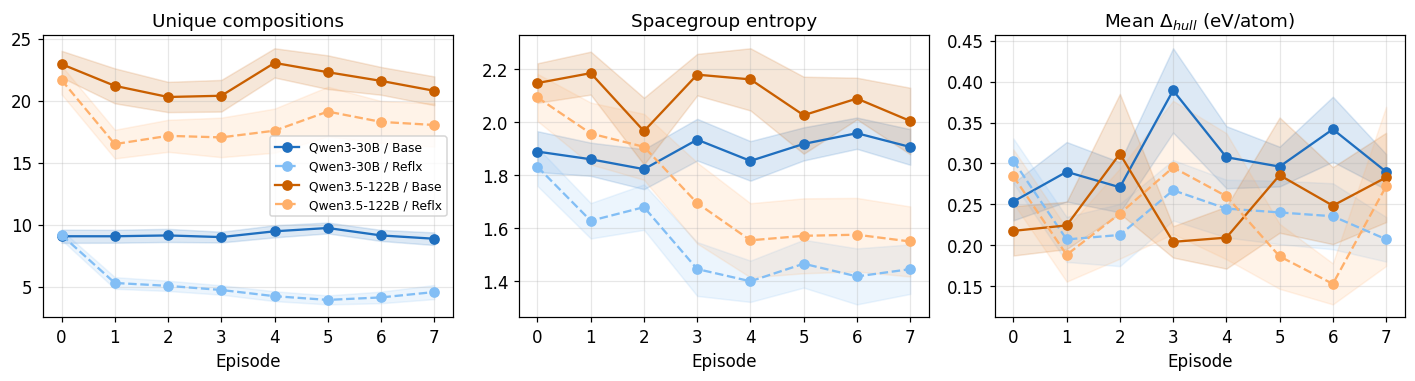

In [26]:
# Per-episode trajectories of the three exploration metrics.
metrics_panel = [
    ('final/diversity_all_composition_unique_composition_count', 'Unique compositions'),
    ('final/diversity_all_structure_spacegroup_entropy',         'Spacegroup entropy'),
    ('final/convex_hull_e_above_hull_mean',                      r'Mean $\Delta_{hull}$ (eV/atom)'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True)
for ax, (metric, title) in zip(axes, metrics_panel):
    for c in configs:
        sub = full_df[full_df['config'] == c]
        if sub.empty:
            continue
        g = sub.groupby('episode')[metric]
        mean = g.mean(); sem = g.std() / np.sqrt(g.count())
        is_reflx = ('reflx' in c) and ('noreflx' not in c)
        ls = '--' if is_reflx else '-'
        ax.plot(mean.index, mean.values, marker='o', linestyle=ls, color=COLORS[c],
                label=PRETTY[c], linewidth=1.5)
        ax.fill_between(mean.index, mean - sem, mean + sem, color=COLORS[c], alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel('Episode')
    ax.grid(True, alpha=0.3)
axes[0].legend(fontsize=8, loc='best')
plt.tight_layout()
plt.savefig(FIG_DIR / 'exploration_metrics.pdf')
plt.show()

## 4. Bonus: matched-pair deltas and tier breakdown
These back the claims in Sections 5.1 (matched-pair wins) and 5.4 (gains larger on harder systems). Drop them into the paper as inline numbers or appendix tables.

In [27]:
def matched_pair_table(df_full, metric):
    sys_mean = df_full.groupby(['model', 'reflexion', 'system'])[metric].mean().reset_index()
    out = []
    for model in sorted(sys_mean['model'].unique()):
        sub = sys_mean[sys_mean['model'] == model]
        piv = sub.pivot(index='system', columns='reflexion', values=metric).dropna()
        if piv.empty:
            continue
        delta = piv[True] - piv[False]
        out.append({
            'model': model,
            'metric': metric.replace('final/', ''),
            'n_systems': len(piv),
            'base_mean': round(piv[False].mean(), 3),
            'reflx_mean': round(piv[True].mean(), 3),
            'mean_delta': round(delta.mean(), 3),
            'wins': int((delta > 0).sum()),
            'losses': int((delta < 0).sum()),
        })
    return pd.DataFrame(out)

matched = pd.concat([
    matched_pair_table(full_df, 'final/num_newly_discovered_stable'),
    matched_pair_table(full_df, 'final/discovery_curve_area_under_discovery_curve_normalized'),
    matched_pair_table(full_df, 'final/stable_discovery_efficiency'),
    matched_pair_table(full_df, 'final/diversity_all_composition_unique_composition_count'),
    matched_pair_table(full_df, 'final/convex_hull_e_above_hull_mean'),
], ignore_index=True)
matched

,model,metric,n_systems,base_mean,reflx_mean,mean_delta,wins,losses
0,qwen3-30b-instr,num_newly_discovered_stable,30,9.821,14.429,4.608,27,3
1,qwen3dot5-122b,num_newly_discovered_stable,19,15.184,21.717,6.533,17,2
2,qwen3-30b-instr,discovery_curve_area_under_discovery_curve_nor...,30,0.267,0.385,0.118,27,3
3,qwen3dot5-122b,discovery_curve_area_under_discovery_curve_nor...,19,0.377,0.558,0.181,18,1
4,qwen3-30b-instr,stable_discovery_efficiency,30,0.246,0.361,0.115,27,3
5,qwen3dot5-122b,stable_discovery_efficiency,19,0.380,0.543,0.163,17,2
6,qwen3-30b-instr,diversity_all_composition_unique_composition_c...,30,9.183,5.142,-4.042,0,30
7,qwen3dot5-122b,diversity_all_composition_unique_composition_c...,19,21.605,17.553,-4.053,4,15
8,qwen3-30b-instr,convex_hull_e_above_hull_mean,30,0.305,0.240,-0.065,8,22
9,qwen3dot5-122b,convex_hull_e_above_hull_mean,19,0.257,0.246,-0.011,10,9


Tier-wise stable-discovery gains (Base → Reflx):


model,Qwen3-30B,Qwen3.5-122B
tier,,
ternary,12.10 → 14.86 (+2.76),16.14 → 20.57 (+4.43)
quaternary,7.97 → 13.44 (+5.46),14.25 → 19.48 (+5.23)
quinary,9.39 → 14.99 (+5.60),16.03 → 22.89 (+6.86)


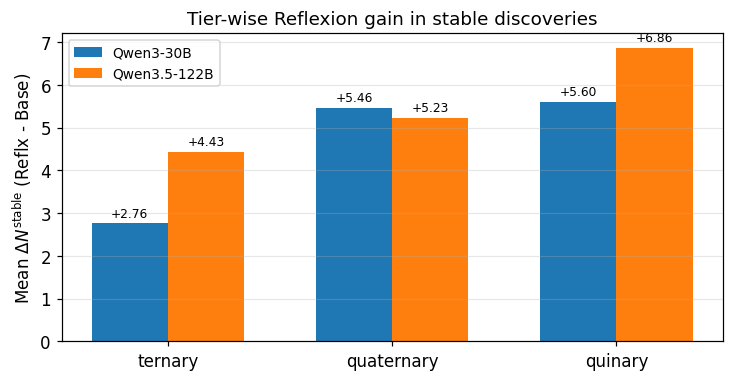

reflexion,tier,model,base_mean,reflx_mean,delta
0,quaternary,qwen3-30b-instr,7.975,13.438,5.462
1,quaternary,qwen3dot5-122b,14.250,19.482,5.232
2,quinary,qwen3-30b-instr,9.388,14.988,5.600
3,quinary,qwen3dot5-122b,16.031,22.891,6.859
4,ternary,qwen3-30b-instr,12.100,14.862,2.763
5,ternary,qwen3dot5-122b,16.143,20.569,4.427


In [28]:
tier_tbl = (
    full_df.groupby(['tier', 'config'])[[
        'final/num_newly_discovered_stable',
        'discoveries_per_gt',
        'final/discovery_curve_area_under_discovery_curve_normalized',
    ]].mean().round(3)
)
tier_tbl

TIER_MODEL_LABELS = {
    'qwen3-30b-instr': 'Qwen3-30B',
    'qwen3dot5-122b': 'Qwen3.5-122B',
}

tier_gain_tbl = (
    full_df.groupby(['tier', 'model', 'reflexion'])['final/num_newly_discovered_stable']
           .mean()
           .unstack('reflexion')
           .rename(columns={False: 'base_mean', True: 'reflx_mean'})
           .reset_index()
)
tier_gain_tbl['delta'] = tier_gain_tbl['reflx_mean'] - tier_gain_tbl['base_mean']
tier_gain_tbl['claim'] = tier_gain_tbl.apply(
    lambda r: f"{r['base_mean']:.2f} → {r['reflx_mean']:.2f} ({r['delta']:+.2f})",
    axis=1,
)
tier_claims = (
    tier_gain_tbl.assign(model=tier_gain_tbl['model'].map(TIER_MODEL_LABELS))
                 .pivot(index='tier', columns='model', values='claim')
                 .reindex(TIERS)
)
print('Tier-wise stable-discovery gains (Base → Reflx):')
display(tier_claims)

fig, ax = plt.subplots(figsize=(6.8, 3.6))
plot_df = tier_gain_tbl.copy()
plot_df['tier'] = pd.Categorical(plot_df['tier'], categories=TIERS, ordered=True)
plot_df = plot_df.sort_values(['tier', 'model'])
x = np.arange(len(TIERS))
width = 0.34
for offset, model in zip([-width / 2, width / 2], ['qwen3-30b-instr', 'qwen3dot5-122b']):
    sub = plot_df[plot_df['model'] == model]
    ax.bar(x + offset, sub['delta'], width=width, label=TIER_MODEL_LABELS[model])
    for xi, yi in zip(x + offset, sub['delta']):
        ax.text(xi, yi + 0.08, f"{yi:+.2f}", ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(TIERS)
ax.set_ylabel(r'Mean $\Delta N^{\mathrm{stable}}$ (Reflx - Base)')
ax.set_title('Tier-wise Reflexion gain in stable discoveries')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / 'tier_gain_by_model.pdf')
plt.show()

tier_gain_tbl[['tier', 'model', 'base_mean', 'reflx_mean', 'delta']].round(3)

## 5. Statistical significance of matched-pair deltas

Wilcoxon signed-rank and one-sided sign test on the per-system deltas $\Delta_s = \bar X^{\mathrm{reflx}}_s - \bar X^{\mathrm{base}}_s$. For yield metrics (N_stable, AUDC_norm, SDE) we test $\Delta > 0$; for exploration metrics (#comp, SG entropy, $\bar\Delta_{hull}$) we test $\Delta < 0$ to back the breadth→depth claim. Sign test is exact binomial on wins-vs-losses.


In [29]:
from scipy.stats import wilcoxon, binomtest

SIG_METRICS = [
    ('final/num_newly_discovered_stable',                              'N_stable',    'greater'),
    ('final/discovery_curve_area_under_discovery_curve_normalized',    'AUDC_norm',   'greater'),
    ('final/stable_discovery_efficiency',                              'SDE',         'greater'),
    ('final/diversity_all_composition_unique_composition_count',       '#comp',       'less'),
    ('final/diversity_all_structure_spacegroup_entropy',               'SG_entropy',  'less'),
    ('final/convex_hull_e_above_hull_mean',                            'mean_dhull',  'less'),
]

def paired_deltas(df_full, metric):
    sys_mean = df_full.groupby(['model', 'reflexion', 'system'])[metric].mean().reset_index()
    out = {}
    for model, sub in sys_mean.groupby('model'):
        piv = sub.pivot(index='system', columns='reflexion', values=metric).dropna()
        if not piv.empty:
            out[model] = (piv[True] - piv[False]).values
    return out

rows = []
for metric, short, direction in SIG_METRICS:
    for model, deltas in paired_deltas(full_df, metric).items():
        n = len(deltas)
        n_pos = int((deltas > 0).sum())
        n_neg = int((deltas < 0).sum())
        n_nz = n_pos + n_neg
        wins = n_pos if direction == 'greater' else n_neg
        try:
            _, w_p = wilcoxon(deltas, zero_method='wilcox', alternative=direction)
        except ValueError:
            w_p = float('nan')
        sign_p = (
            binomtest(wins, n_nz, p=0.5, alternative='greater').pvalue
            if n_nz else float('nan')
        )
        rows.append({
            'model': model,
            'metric': short,
            'dir': direction,
            'n': n,
            'wins': wins,
            'mean_delta':   round(float(np.mean(deltas)), 3),
            'median_delta': round(float(np.median(deltas)), 3),
            'wilcoxon_p': f'{w_p:.2e}',
            'sign_p':    f'{sign_p:.2e}',
        })
sig_df = pd.DataFrame(rows)
from IPython.display import Markdown
Markdown(sig_df.to_markdown())


|    | model           | metric     | dir     |   n |   wins |   mean_delta |   median_delta |   wilcoxon_p |   sign_p |
|---:|:----------------|:-----------|:--------|----:|-------:|-------------:|---------------:|-------------:|---------:|
|  0 | qwen3-30b-instr | N_stable   | greater |  30 |     27 |        4.608 |          4.812 |     1.08e-05 | 4.22e-06 |
|  1 | qwen3dot5-122b  | N_stable   | greater |  19 |     17 |        6.533 |          7     |     0.000268 | 0.000364 |
|  2 | qwen3-30b-instr | AUDC_norm  | greater |  30 |     27 |        0.118 |          0.121 |     2.99e-06 | 4.22e-06 |
|  3 | qwen3dot5-122b  | AUDC_norm  | greater |  19 |     18 |        0.181 |          0.181 |     2.67e-05 | 3.81e-05 |
|  4 | qwen3-30b-instr | SDE        | greater |  30 |     27 |        0.115 |          0.12  |     1.08e-05 | 4.22e-06 |
|  5 | qwen3dot5-122b  | SDE        | greater |  19 |     17 |        0.163 |          0.175 |     0.000269 | 0.000364 |
|  6 | qwen3-30b-instr | #comp      | less    |  30 |     30 |       -4.042 |         -3.812 |     8.6e-07  | 9.31e-10 |
|  7 | qwen3dot5-122b  | #comp      | less    |  19 |     15 |       -4.053 |         -2.75  |     0.00266  | 0.00961  |
|  8 | qwen3-30b-instr | SG_entropy | less    |  30 |     26 |       -0.355 |         -0.355 |     1.28e-07 | 2.97e-05 |
|  9 | qwen3dot5-122b  | SG_entropy | less    |  19 |     17 |       -0.421 |         -0.429 |     1.34e-05 | 0.000364 |
| 10 | qwen3-30b-instr | mean_dhull | less    |  30 |     22 |       -0.065 |         -0.092 |     0.0053   | 0.00806  |
| 11 | qwen3dot5-122b  | mean_dhull | less    |  19 |      9 |       -0.011 |          0     |     0.43     | 0.676    |

## Appendix: Notable Reflector Observations

Sampled from `results/smoke/custom/` across 72 `reflections.json` files (qwen3-30b-instr-reflx and qwen3dot5-122b-reflx, ternary/quaternary/quinary systems, April 2026 runs). Each file is a list of reflection strings produced after each episode; index 0 is sometimes a placeholder `{reflection}`.

---

### 1. Au-Tb-V-Y — Explicit acknowledgment of ignored advice
**Model:** qwen3dot5-122b-reflx · **System:** Au-Tb-V-Y (quaternary) · **Reflection index:** 2

> *"**Track and implement prior reflections:** This episode ignored key lessons from previous runs; maintain a checklist of prior reflections at episode start to ensure carry-forward of insights."*

Also notes that prior reflections explicitly recommended testing Tb/Y binaries, but the actor continued to saturate Au-V instead.

---

### 2. Ga-Ho-Lu — Escalating frustration over repeated violations
**Model:** qwen3dot5-122b-reflx · **System:** Ga-Ho-Lu (ternary)

Index 2:
> *"**Enforce System-Level Deduplication:** ... **repeated advice has been violated**, and ~11 wasted queries directly reduced coverage of the missing ground-truth phase."*

By the later reflection the wasted query count had grown to **~16**, as the actor continued re-querying known compositions despite the warning.

---

### 3. Ca-Fe-Gd-Pb-Tb — 36 queries on a dead composition
**Model:** qwen3-30b-instr-reflx · **System:** Ca-Fe-Gd-Pb-Tb (quinary)

> *"Discontinue all queries on Ca1 Gd1 Pb3 immediately — despite prior optimism, it produced no stable structures and **consumed 36 queries without return**."*

The same composition is called out again in the next reflection, having apparently continued anyway.

---

### 4. Co-Pd-Tl — Query cap ratcheted down three times
**Model:** qwen3-30b-instr-reflx · **System:** Co-Pd-Tl (ternary)

The cap on Pd1Tl3 queries is reduced across successive reflections: **20–25 → 10–15 → 8–10**, each with increasingly firm "cease querying immediately" language, implying the actor kept over-querying despite each prior warning.

---

### 5. Ba-Be-Hf-Li — Prior episodes over-invested despite warnings
**Model:** qwen3-30b-instr-reflx · **System:** Ba-Be-Hf-Li (quaternary) · **Reflection index:** 2

> *"Do not allocate more than 10 queries to Be1 Hf1, and apply early stopping after 2 unstable results — **prior episodes over-invested here despite high variance and low stability yield**."*

---

### Summary of patterns

| Pattern | Best example |
|---|---|
| Explicit "ignored advice" statement | Au-Tb-V-Y (index 2) |
| Escalating wasted-query count across reflections | Ga-Ho-Lu (~11 → ~16 wasted) |
| Same composition called out in successive reflections | Ca-Fe-Gd-Pb-Tb (36 queries wasted) |
| Recommendation ratcheted down each episode | Co-Pd-Tl (20→10→8 query cap) |
| "Prior episodes over-invested despite warnings" | Ba-Be-Hf-Li |

The most direct single line in the corpus is from Au-Tb-V-Y: **"This episode ignored key lessons from previous runs"** — the reflector explicitly naming the actor's failure to carry forward guidance.